# Asymptotic Bode

Goal:
* Express the frequency response of a system defined by a transfer function as piecewise linear funtions.

## Preparations

In [41]:
import numpy as np

from sympy import *
from sympy.physics.control.lti import TransferFunction

from mathprint import *

import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 10,
})

Define variables that we are going to use repetitively:
$s$, $t$ and $\omega$.
We also need to define specific prpoperties of the variables.

In [42]:
t        = symbols('t'       , real=True)
s        = symbols('s'       , complex=True)
omega    = symbols('omega'   , positive=True)
a, b     = symbols('a b'     , real=True)
c        = symbols('c  '     , complex=True)
zeta     = symbols('zeta'    , real=True)
omega_n  = symbols('omega_n' , positive=True)

## Asymptotic Bode Plots of Low-Order Transfer Functions

These are the fundamental steps that we must do to plot the frequence response (Bode plot) of a system defined by a transfer function $H(s)$:
* Do substitution: $s = j \omega$
* Compute $H(j \omega )$
* The result is a complex number:
    * Extract the magnitude: $ 20 \log_{10} \big| H(j\omega) \big| $
    * Extract the the phase: $ \angle H(j \omega) $

It is very easy to execute those steps by using a computer. On the other hand, when we simply want to sketch the Bode plot without using a computer, we can use the asymptotic method to draw the approximated version of the Bode plot.


### Case 1: A pole at the origin of the s-plane

In [43]:
H1 = 1/s
mprint('H(s)=', latex(H1))

<IPython.core.display.Math object>

After the substitution, we then obtain:

In [44]:
Hjw  = H1.subs(s, I*omega)
M1   = simplify(20 * log(Abs(Hjw), 10))
Phi1 = arg(Hjw)
mprint("M (\\omega) =", latex(M1))
mprint("\\phi ( \\omega ) =", latex(Phi1))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Magnitude plot

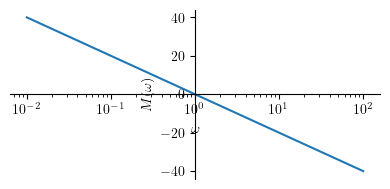

In [45]:
ylabel = '$ M ( \\omega ) $'
p1 = plot(M1, (omega, 0.01 , 100), size=(4, 2), ylabel=ylabel, show=True,  xscale='log')

#### Phase plot

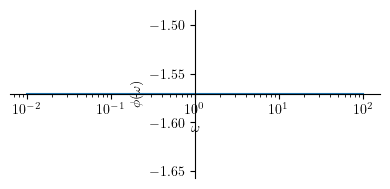

In [46]:
ylabel = '$\\phi ( \\omega ) $'
p2 = plot(Phi1, (omega, 0.01 , 100), size=(4, 2), ylabel=ylabel, show=True,  xscale='log')

### Case 2: A zero at the origin of the s-plane

In [47]:
H2 = s
mprint('H(s)=', latex(H2))

<IPython.core.display.Math object>

After the substitution, we then obtain:

In [48]:
Hjw  = H2.subs(s, I*omega)
M2   = simplify(20 * log(Abs(Hjw), 10))
Phi2 = arg(Hjw)
mprintb("M (\\omega) =", latex(M2))
mprintb("\\phi ( \\omega ) =", latex(Phi2))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Magnitude plot

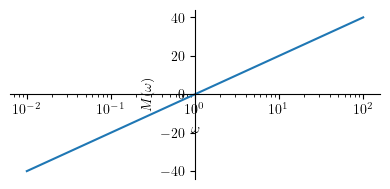

In [49]:
ylabel = '$M ( \\omega )$'
p1 = plot(M2, (omega, 0.01 , 100), size=(4, 2), ylabel=ylabel, show=True,  xscale='log')

#### Phase plot

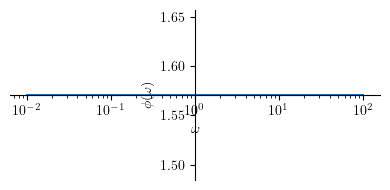

In [50]:
ylabel = '$\\phi ( \\omega ) $'
p2 = plot(Phi2, (omega, 0.01 , 100), size=(4, 2), ylabel=ylabel, show=True,  xscale='log')

### Case 3: A single real pole

In [51]:
H3 = 1/(s+a)
mprint('H(s)=', latex(H3))

<IPython.core.display.Math object>

After the substitution, we then obtain:

In [52]:
Hjw = H3.subs(s, I*omega)
M3   = simplify(20 * log(Abs(Hjw), 10))
Phi3 = arg(Hjw)
mprintb("M (\\omega) =", latex(M3))
mprintb("\\phi ( \\omega ) =", latex(Phi3))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Magnitude plot

Now, let us plot the results for both the magnitude and the phase. However, we must first set a numerical value for $a$. Let us set $a=1$.

Before that, let us write down the approximated version of the plots. What we do here is a bit based on observations. 

In [53]:
a_ = 1

In [54]:
Mhat3 = Piecewise((-20 * log(a, 10), omega <= a),
                 (-20 * log(omega, 10), True))
mprintb("\\hat{ M } ( \\omega ) = ", latex(Mhat3))

<IPython.core.display.Math object>

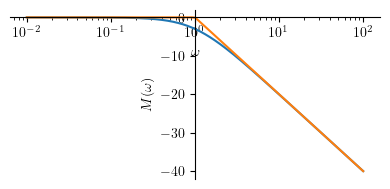

In [55]:
ylabel = '$M ( \\omega )$'
p1 = plot(M3.subs(a, a_),    (omega, a_/100 , 100*a_), size=(4, 2), ylabel=ylabel, show=False,  xscale='log')
p2 = plot(Mhat3.subs(a, a_), (omega, a_/100 , 100*a_), show=False)
p1.append(p2[0])
p1.show()

#### Phase

In [56]:
Phihat3 = Piecewise((0, omega <= 0.1*a),
                    (-pi/4 * log(omega/(0.1*a), 10) , omega < a*10), 
                    (-pi/2, True))
mprintb("\\hat{ \\phi } ( \\omega ) = ", latex(simplify(Phihat3)))

<IPython.core.display.Math object>

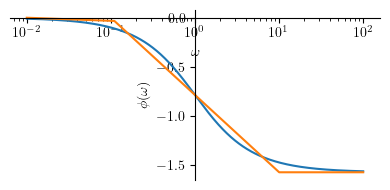

In [57]:
ylabel = '$\\phi ( \\omega ) $'
p1 = plot(Phi3.subs(a, a_),    (omega, a_/100 , 100*a_), size=(4, 2), ylabel=ylabel, show=False,  xscale='log')
p2 = plot(Phihat3.subs(a, a_), (omega, a_/100 , 100*a_), show=False)
p1.append(p2[0])
p1.show()

### Case 4: A single real zero

In [58]:
H4 = s+a
mprint('H(s)=', latex(H4))

<IPython.core.display.Math object>

After the substitution, we then obtain:

In [59]:
Hjw  = H4.subs(s, I*omega)
M4   = simplify(20 * log(Abs(Hjw), 10))
Phi4 = arg(Hjw)
mprint("M (\\omega) =", latex(M4))
mprint("\\phi ( \\omega ) =", latex(Phi4))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Magnitude plot

Now, let us plot the results for both the magnitude and the phase. However, we must first set a numerical value for $a$. Let us set $a=1$.

Before that, let us write down the approximated version of the plots. What we do here is a bit based on observations. 

In [60]:
Mhat4 = Piecewise((20 * log(a, 10), omega <= a),
                  (20 * log(omega, 10), True))
mprintb("\\hat{ M } ( \\omega ) = ", latex(Mhat4))

<IPython.core.display.Math object>

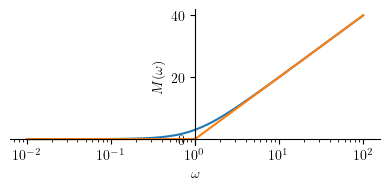

In [61]:
ylabel = '$M ( \\omega )$'
p1 = plot(M4.subs(a, a_),    (omega, a_/100 , 100*a_), size=(4, 2), ylabel=ylabel, show=False,  xscale='log')
p2 = plot(Mhat4.subs(a, a_), (omega, a_/100 , 100*a_), show=False)
p1.append(p2[0])
p1.show()

#### Phase plot

In [62]:
Phihat4 = Piecewise((0, omega <= 0.1*a),
                    (pi/4 * log(omega/(0.1*a), 10) , omega < a*10), 
                    (pi/2, True))
mprintb("\\hat{ \\phi } ( \\omega ) = ", latex(simplify(Phihat4)))

<IPython.core.display.Math object>

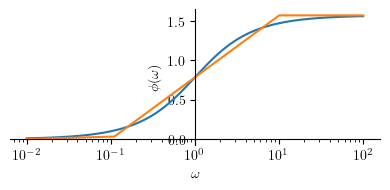

In [63]:
ylabel = '$\\phi ( \\omega ) $'
p1 = plot(Phi4.subs(a, a_),    (omega, a_/100 , 100*a_), size=(4, 2), ylabel=ylabel, show=False,  xscale='log')
p2 = plot(Phihat4.subs(a, a_), (omega, a_/100 , 100*a_), show=False)
p1.append(p2[0])
p1.show()

### Case 5: Complex Conjugate Pole Pair

In [64]:
H5 = 1 / (s**2 + 2*zeta*omega_n*s + omega_n**2)
mprint('H(s)=', latex(H5))

<IPython.core.display.Math object>

By substituting $s$ with $j \omega$, we can obtain:

In [65]:
Hjw  = H5.subs(s, I*omega)
M5   = expand_log(20 * log(Abs(Hjw), 10))
Phi5 = arg(Hjw)
mprint("M (\\omega) =", latex(M5))
mprint("\\phi ( \\omega ) =", latex(Phi5))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Resonance peak

Complex conjugate pole pair occurs when $\zeta < 1$. When $\zeta < 1$, the system is underdamped. Resonance peak appears in the Bode magnitude plot at $\omega = \omega_n$. The magnitude at this resonance peak can be computed as: 

In [66]:
Mp = M5.subs(omega, omega_n)
mprintb("M_p = ", latex(Mp))

<IPython.core.display.Math object>

#### Magnitude Plot

Now, let's express the asymptotic Bode plot as piecewise functions. At the moment, we will do this by intuition.

In [67]:
Mhat5 = Piecewise((-40 * log(omega_n, 10), omega < omega_n),
                  (Mp, (omega >= omega_n) & (omega <= omega_n)),
                  (-40 * log(omega, 10), omega > omega_n))
mprintb("\\hat{ M } ( \\omega ) = ", latex(Mhat5))

<IPython.core.display.Math object>

For the actual plotting, we need to define some numerical values for:

In [68]:
omega_n_ = 1
zeta_ = [0.1, 0.2, 0.5] # plot for several values

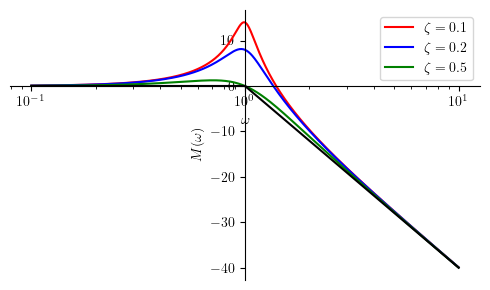

In [69]:
ylabel = '$M ( \\omega )$'
p1 = plot(M5.subs(([omega_n, omega_n_],[zeta, zeta_[0]])),    (omega, omega_n_/10 , 10*omega_n_), line_color='r', size=(5, 3), ylabel=ylabel, show=False,  xscale='log', legend=True)
p2 = plot(M5.subs(([omega_n, omega_n_],[zeta, zeta_[1]])),    (omega, omega_n_/10 , 10*omega_n_), line_color='b', show=False)
p3 = plot(M5.subs(([omega_n, omega_n_],[zeta, zeta_[2]])),    (omega, omega_n_/10 , 10*omega_n_), line_color='g', show=False)
p4 = plot(Mhat5.subs(([omega_n, omega_n_],[zeta, zeta_[0]])), (omega, omega_n_/10 , 10*omega_n_), line_color='k', show=False)

p1[0].label = "$\\zeta=" + str(zeta_[0]) + "$"
p2[0].label = "$\\zeta=" + str(zeta_[1]) + "$"
p3[0].label = "$\\zeta=" + str(zeta_[2]) + "$"
p4[0].label = ""

p1.append(p2[0])
p1.append(p3[0])
p1.append(p4[0])

p1.show()

The general shape of the asymptotic magnitude plot is not affected by $\zeta$.
 
Although we do have the resonance peak in the piecewise Bode, __SymPy fails to plot the resonance peak for some technical reasons.__ However, we can still compute this peak value by using the equation expressed by $M_p$:

In [70]:
print(Mp.subs(([omega_n, omega_n_],[zeta, zeta_[0]])).evalf()) # for zeta[0]
print(Mp.subs(([omega_n, omega_n_],[zeta, zeta_[1]])).evalf()) # for zeta[1]
print(Mp.subs(([omega_n, omega_n_],[zeta, zeta_[2]])).evalf()) # for zeta[2]

13.9794000867204
7.95880017344075
0


#### Phase plot

In [71]:
Phihat5 = Piecewise((0, omega <= (omega_n / 10**zeta)),
                    (-pi/(2*zeta) * log(omega/(10**(-zeta)*omega_n), 10) , omega < (omega_n*10**zeta)), 
                    (-pi, True))
mprintb("\\hat{ \\phi } ( \\omega ) = ", latex(simplify(Phihat5)))

<IPython.core.display.Math object>

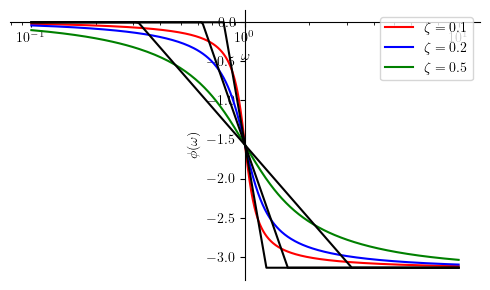

In [72]:
ylabel = '$\\phi ( \\omega ) $'
p1 = plot(Phi5.subs(([omega_n, omega_n_],[zeta, zeta_[0]])),    (omega, omega_n_/10 , 10*omega_n_), line_color='r', size=(5, 3), ylabel=ylabel, show=False,  xscale='log', legend=True)
p2 = plot(Phi5.subs(([omega_n, omega_n_],[zeta, zeta_[1]])),    (omega, omega_n_/10 , 10*omega_n_), line_color='b', show=False)
p3 = plot(Phi5.subs(([omega_n, omega_n_],[zeta, zeta_[2]])),    (omega, omega_n_/10 , 10*omega_n_), line_color='g', show=False)

p4 = plot(Phihat5.subs(([omega_n, omega_n_],[zeta, zeta_[0]])), (omega, omega_n_/10 , 10*omega_n_), line_color='k', show=False)
p5 = plot(Phihat5.subs(([omega_n, omega_n_],[zeta, zeta_[1]])), (omega, omega_n_/10 , 10*omega_n_), line_color='k', show=False)
p6 = plot(Phihat5.subs(([omega_n, omega_n_],[zeta, zeta_[2]])), (omega, omega_n_/10 , 10*omega_n_), line_color='k', show=False)


p1[0].label = "$\\zeta=" + str(zeta_[0]) + "$"
p2[0].label = "$\\zeta=" + str(zeta_[1]) + "$"
p3[0].label = "$\\zeta=" + str(zeta_[2]) + "$"
p4[0].label = ""
p5[0].label = ""
p6[0].label = ""

p1.append(p2[0])
p1.append(p3[0])
p1.append(p4[0])
p1.append(p5[0])
p1.append(p6[0])

p1.show()

### Case 6: Complex Conjugate Zero Pair

In [73]:
H6 = (s**2 + 2*zeta*omega_n*s + omega_n**2) / (omega_n**2) 
mprint('H(s)=', latex(H6))

<IPython.core.display.Math object>

In [74]:
Hjw  = H6.subs(s, I*omega)
M6   = simplify(20 * log(Abs(Hjw), 10))
Phi6 = arg(Hjw)
mprint("M (\\omega) =", latex(M6))
mprint("\\phi ( \\omega ) =", latex(Phi6))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Resonance Peak

Complex conjugate zero pair occurs when $\zeta < 1$. Resonance peak appears in the Bode magnitude plot at $\omega = \omega_n$. The magnitude at this resonance peak can be computed as: 

In [75]:
Mp = M6.subs(omega, omega_n)
mprintb("M_p = ", latex(Mp))

<IPython.core.display.Math object>

#### Magnitude Plot

We first present the piecewise logarithmic representation of the asymptotic Bode plot. After that, we present the plot for several diffrent values for $\zeta$.

In [76]:
Mhat6 = Piecewise((40 * log(omega_n, 10), omega < omega_n),
                  (Mp, (omega >= omega_n) & (omega <= omega_n)),
                  (40 * log(omega, 10), omega > omega_n))
mprintb("\\hat{ M } ( \\omega ) = ", latex(Mhat6))

<IPython.core.display.Math object>

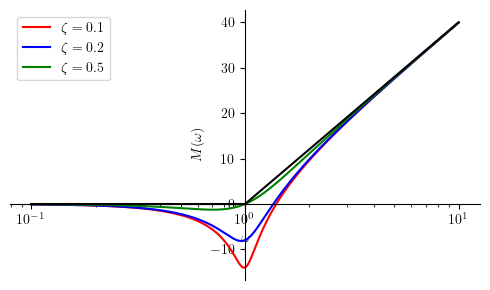

In [77]:
ylabel = '$M ( \\omega )$'
p1 = plot(M6.subs(([omega_n, omega_n_],[zeta, zeta_[0]])),    (omega, omega_n_/10 , 10*omega_n_), line_color='r', size=(5, 3), ylabel=ylabel, show=False,  xscale='log', legend=True)
p2 = plot(M6.subs(([omega_n, omega_n_],[zeta, zeta_[1]])),    (omega, omega_n_/10 , 10*omega_n_), line_color='b', show=False)
p3 = plot(M6.subs(([omega_n, omega_n_],[zeta, zeta_[2]])),    (omega, omega_n_/10 , 10*omega_n_), line_color='g', show=False)
p4 = plot(Mhat6.subs(([omega_n, omega_n_],[zeta, zeta_[0]])), (omega, omega_n_/10 , 10*omega_n_), line_color='k', show=False)

p1[0].label = "$\\zeta=" + str(zeta_[0]) + "$"
p2[0].label = "$\\zeta=" + str(zeta_[1]) + "$"
p3[0].label = "$\\zeta=" + str(zeta_[2]) + "$"
p4[0].label = ""

p1.append(p2[0])
p1.append(p3[0])
p1.append(p4[0])

p1.show()

#### Phase plot

Similar to the prevoius section, we first present the piecewise logarithmic representation of the asymptotic Bode plot. After that, we present the plot for several diffrent values for $\zeta$.

In [78]:
Phihat6 = Piecewise((0, omega <= (omega_n / 10**zeta)),
                    (pi/(2*zeta) * log(omega/(10**(-zeta)*omega_n), 10) , omega < (omega_n*10**zeta)), 
                    (pi, True))
mprintb("\\hat{ \\phi } ( \\omega ) = ", latex(simplify(Phihat6)))

<IPython.core.display.Math object>

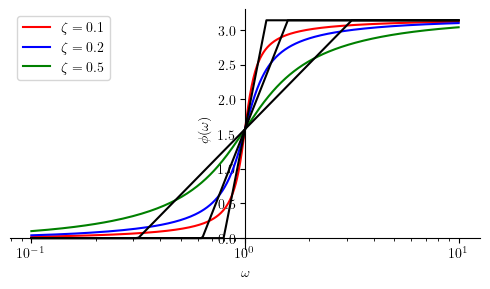

In [79]:
ylabel = '$\\phi ( \\omega ) $'
p1 = plot(Phi6.subs(([omega_n, omega_n_],[zeta, zeta_[0]])),    (omega, omega_n_/10 , 10*omega_n_), line_color='r', size=(5, 3), ylabel=ylabel, show=False,  xscale='log', legend=True)
p2 = plot(Phi6.subs(([omega_n, omega_n_],[zeta, zeta_[1]])),    (omega, omega_n_/10 , 10*omega_n_), line_color='b', show=False)
p3 = plot(Phi6.subs(([omega_n, omega_n_],[zeta, zeta_[2]])),    (omega, omega_n_/10 , 10*omega_n_), line_color='g', show=False)

p4 = plot(Phihat6.subs(([omega_n, omega_n_],[zeta, zeta_[0]])), (omega, omega_n_/10 , 10*omega_n_), line_color='k', show=False)
p5 = plot(Phihat6.subs(([omega_n, omega_n_],[zeta, zeta_[1]])), (omega, omega_n_/10 , 10*omega_n_), line_color='k', show=False)
p6 = plot(Phihat6.subs(([omega_n, omega_n_],[zeta, zeta_[2]])), (omega, omega_n_/10 , 10*omega_n_), line_color='k', show=False)

p1.append(p2[0])
p1.append(p3[0])
p1.append(p4[0])
p1.append(p5[0])
p1.append(p6[0])

p1[0].label = "$\\zeta=" + str(zeta_[0]) + "$"
p2[0].label = "$\\zeta=" + str(zeta_[1]) + "$"
p3[0].label = "$\\zeta=" + str(zeta_[2]) + "$"
p4[0].label = ""
p5[0].label = ""
p6[0].label = ""


p1.show()

### Summary

Finally, let us summarize all boxed formulas.

In [80]:
from pandas import DataFrame
from IPython.display import Markdown

def makelatex(args):
    return ["$$ {} $$".format(latex(a)) for a in args]

desc = ["A pole at the origin", 
        "A zero at the origin",
        "A single real pole",
        "A single real zero", 
        "A Complex Conjugate Pole Pair", 
        "A Complex Conjugate Zero Pair"]
Hs   = [H1, H2, H3, H4, H5, H6]
Ms   = [M1, M2, Mhat3, Mhat4, Mhat5, Mhat6]
Phis = [Phi1, Phi2, Phihat3, Phihat4, Phihat5, Phihat6]

dic = {'Description': desc, 
       '$H(s)$': makelatex(Hs), 
       '$M( \\omega )$': makelatex(Ms), 
       '$\\phi( \\omega )$': makelatex(Phis)}

df = DataFrame(dic)


Markdown(df.to_markdown())

|    | Description                   | $H(s)$                                                                     | $M( \omega )$                                                                                                                                                                                                                                                                                                                                        | $\phi( \omega )$                                                                                                                                                                                                                                                      |
|---:|:------------------------------|:---------------------------------------------------------------------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|  0 | A pole at the origin          | $$ \frac{1}{s} $$                                                          | $$ - \frac{20 \log{\left(\omega \right)}}{\log{\left(10 \right)}} $$                                                                                                                                                                                                                                                                                 | $$ - \frac{\pi}{2} $$                                                                                                                                                                                                                                                 |
|  1 | A zero at the origin          | $$ s $$                                                                    | $$ \frac{20 \log{\left(\omega \right)}}{\log{\left(10 \right)}} $$                                                                                                                                                                                                                                                                                   | $$ \frac{\pi}{2} $$                                                                                                                                                                                                                                                   |
|  2 | A single real pole            | $$ \frac{1}{a + s} $$                                                      | $$ \begin{cases} - \frac{20 \log{\left(a \right)}}{\log{\left(10 \right)}} & \text{for}\: a \geq \omega \\- \frac{20 \log{\left(\omega \right)}}{\log{\left(10 \right)}} & \text{otherwise} \end{cases} $$                                                                                                                                           | $$ \begin{cases} 0 & \text{for}\: \omega \leq 0.1 a \\- \frac{\pi \log{\left(\frac{10.0 \omega}{a} \right)}}{4 \log{\left(10 \right)}} & \text{for}\: \omega < 10 a \\- \frac{\pi}{2} & \text{otherwise} \end{cases} $$                                               |
|  3 | A single real zero            | $$ a + s $$                                                                | $$ \begin{cases} \frac{20 \log{\left(a \right)}}{\log{\left(10 \right)}} & \text{for}\: a \geq \omega \\\frac{20 \log{\left(\omega \right)}}{\log{\left(10 \right)}} & \text{otherwise} \end{cases} $$                                                                                                                                               | $$ \begin{cases} 0 & \text{for}\: \omega \leq 0.1 a \\\frac{\pi \log{\left(\frac{10.0 \omega}{a} \right)}}{4 \log{\left(10 \right)}} & \text{for}\: \omega < 10 a \\\frac{\pi}{2} & \text{otherwise} \end{cases} $$                                                   |
|  4 | A Complex Conjugate Pole Pair | $$ \frac{1}{\omega_{n}^{2} + 2 \omega_{n} s \zeta + s^{2}} $$              | $$ \begin{cases} - \frac{40 \log{\left(\omega_{n} \right)}}{\log{\left(10 \right)}} & \text{for}\: \omega < \omega_{n} \\- \frac{10 \log{\left(4 \omega_{n}^{4} \zeta^{2} \right)}}{\log{\left(10 \right)}} & \text{for}\: \omega \leq \omega_{n} \\- \frac{40 \log{\left(\omega \right)}}{\log{\left(10 \right)}} & \text{otherwise} \end{cases} $$ | $$ \begin{cases} 0 & \text{for}\: \omega \leq 10^{- \zeta} \omega_{n} \\- \frac{\pi \log{\left(\frac{10^{\zeta} \omega}{\omega_{n}} \right)}}{2 \zeta \log{\left(10 \right)}} & \text{for}\: \omega < 10^{\zeta} \omega_{n} \\- \pi & \text{otherwise} \end{cases} $$ |
|  5 | A Complex Conjugate Zero Pair | $$ \frac{\omega_{n}^{2} + 2 \omega_{n} s \zeta + s^{2}}{\omega_{n}^{2}} $$ | $$ \begin{cases} \frac{40 \log{\left(\omega_{n} \right)}}{\log{\left(10 \right)}} & \text{for}\: \omega < \omega_{n} \\\frac{10 \log{\left(4 \zeta^{2} \right)}}{\log{\left(10 \right)}} & \text{for}\: \omega \leq \omega_{n} \\\frac{40 \log{\left(\omega \right)}}{\log{\left(10 \right)}} & \text{otherwise} \end{cases} $$                      | $$ \begin{cases} 0 & \text{for}\: \omega \leq 10^{- \zeta} \omega_{n} \\\frac{\pi \log{\left(\frac{10^{\zeta} \omega}{\omega_{n}} \right)}}{2 \zeta \log{\left(10 \right)}} & \text{for}\: \omega < 10^{\zeta} \omega_{n} \\\pi & \text{otherwise} \end{cases} $$     |